In [1]:
import pandas as pd 
import geopandas as gpd 
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt 
from functions.funcs import *
from ast import literal_eval
from scipy.stats import binned_statistic_2d
import matplotlib.colors as colors

In [2]:
def Rolling_avg_no_nan(list, window):
    x = Rolling_mean(list, window)
    x = np.array(x)
    masked = ~np.isnan(x)
    x = x[masked]
    return x

In [3]:
ds = gpd.read_parquet(r"Data\Mapped_4hr_period.parquet")
ds = Add_x_y_speed_collums(ds)
ds.columns
avg_xspeed = []
avg_yspeed = []
avg_speed = []

for i in range(len(ds)):
    xspeed = ds.at[i,"x_speed"]
    yspeed = ds.at[i,"y_speed"]
    speed = ds.at[i,"xy_speed"]

    #xspeed = Rolling_mean(xspeed, 6)
    #yspeed = Rolling_mean(yspeed,6)
    #speed = Rolling_mean(speed,6)
    avg_xspeed.append(xspeed)
    avg_yspeed.append(yspeed)
    avg_speed.append(speed)

ds["avg_xspeed"] = avg_xspeed
ds["avg_yspeed"] = avg_yspeed
ds["avg_speed"] = avg_speed


In [4]:
def Add_Delta_speeds(ds = gpd.GeoDataFrame):
    """Provides columns deltax_speed, deltay_speed, delta_speed. 
    Which are the diffence between the dFAD speeds and model speeds
    returns the dataset with added columns"""

    delta_xspeeds = []
    delta_yspeeds = []
    delta_speeds = []

    for i in range(len(ds)):
        mapped_x = ds["mapped_u"][i]
        dfad_x = ds["avg_xspeed"][i]
        deltax = mapped_x[:-1] - dfad_x
        #Y values
        mapped_y = ds["mapped_v"][i]
        dfad_y = ds["avg_yspeed"][i]
        deltay = mapped_y[:-1] - dfad_y
        #speed 
        mapped = ds["mapped_speed"][i]
        dfad = ds["avg_speed"][i]
        delta = mapped[:-1] - dfad

        delta_xspeeds.append(deltax)
        delta_yspeeds.append(deltay)
        delta_speeds.append(delta)

    ds["deltax_speed"] = delta_xspeeds
    ds["deltay_speed"] = delta_yspeeds
    ds["delta_speed"] = delta_speeds
    return ds

In [5]:
ds = Add_Mapped_speeds(ds)
ds = Add_Delta_speeds(ds)

#### Plotting Speeds Errors Lat,Lon

In [6]:
delxs = []
delys = []
delspeeds = []

for i in range(len(ds)):
    delx = ds["deltax_speed"][i]
    dely = ds["deltay_speed"][i]
    delspeed = ds["delta_speed"][i]
    delxs.extend(delx)
    delys.extend(dely)
    delspeeds.extend(delspeed)


In [7]:
##gives list of lat lons 
lines = ds["geometry"]

points = np.empty((1,2))
for n in range(0,len(lines)):
    dummyline = lines[n]
    cords  = np.array(dummyline.coords)
    cords = cords[:-1]
    points = np.append(points,cords, axis= 0 )

rotatedpoints = np.rot90(points) 
print(rotatedpoints.shape) ##this gives us all of lats in first row and all of the lon in second row 

lat  = rotatedpoints[0][1:]
lon = rotatedpoints[1][1:]

(2, 33680)


In [8]:
if True:
    x_speeds = binned_statistic_2d(lon, lat, delxs, statistic= np.nanmean, bins = 20)
    y_speeds= binned_statistic_2d(lat,lon,delys,statistic= np.nanmean, bins = 20)
    speeds = binned_statistic_2d(lat,lon,delspeeds,statistic= np.nanmean, bins = 20)

if False:
    x_speeds = binned_statistic_2d(lon, lat, np.abs(delxs), statistic= "mean", bins = 20)
    y_speeds= binned_statistic_2d(lat,lon, np.abs(delys),statistic= "mean", bins = 20)
    speeds = binned_statistic_2d(lat,lon,np.abs(delspeeds),statistic= "mean", bins = 20)

x_bounds = x_speeds[1]
y_bounds = y_speeds[1]

X,Y = np.meshgrid(x_bounds, y_bounds)

avgxcorrection = np.mean(x_speeds[0])
avgycorrection =np.mean(y_speeds[0])
avgxycorrection =np.mean(speeds[0])

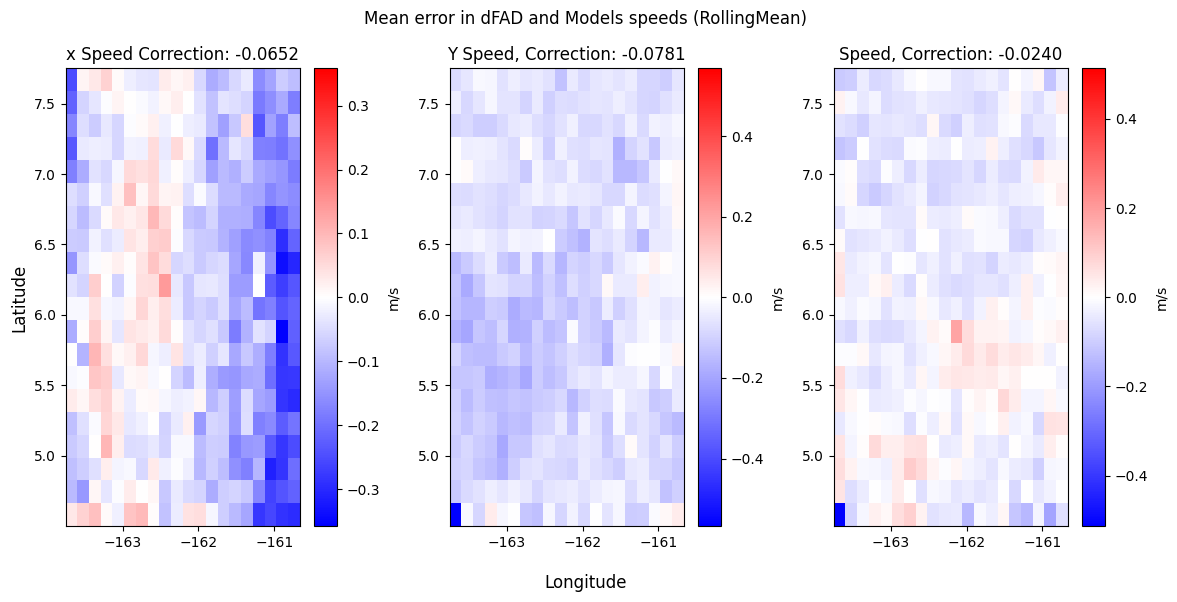

In [9]:
fig, ax = plt.subplots(1,3,figsize = (12,6))
cbr = ax[0].pcolormesh(X,Y,x_speeds[0],cmap = "bwr", norm=colors.CenteredNorm()) ##GnBu
ax[0].set_title(f"x Speed Correction: {avgxcorrection:.4f}")
cbar = fig.colorbar(cbr)
cbar.set_label("m/s")
#cbr.set_clim(0,0.75)
cbr = ax[1].pcolormesh(X,Y,y_speeds[0],cmap = "bwr",norm=colors.CenteredNorm())
ax[1].set_title(f"Y Speed, Correction: {avgycorrection:.4f}")
cbar = fig.colorbar(cbr)
cbar.set_label("m/s")
#cbr.set_clim(0,0.25)
cbr = ax[2].pcolormesh(X,Y,speeds[0],cmap = "bwr",norm=colors.CenteredNorm())
ax[2].set_title(f"Speed, Correction: {avgxycorrection:.4f}")
cbar = fig.colorbar(cbr)
cbar.set_label("m/s")
#cbr.set_clim(0,0.25)
fig.supxlabel("Longitude")
fig.supylabel("Latitude")
fig.suptitle("Mean error in dFAD and Models speeds (RollingMean)")
fig.tight_layout()
fig.savefig(rf"..\Figures\Speed_Differences_2.png")


#### Plotting Speed of dFAD vs Speed of Ocean Model 

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_16680\3304940340.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,1].legend()


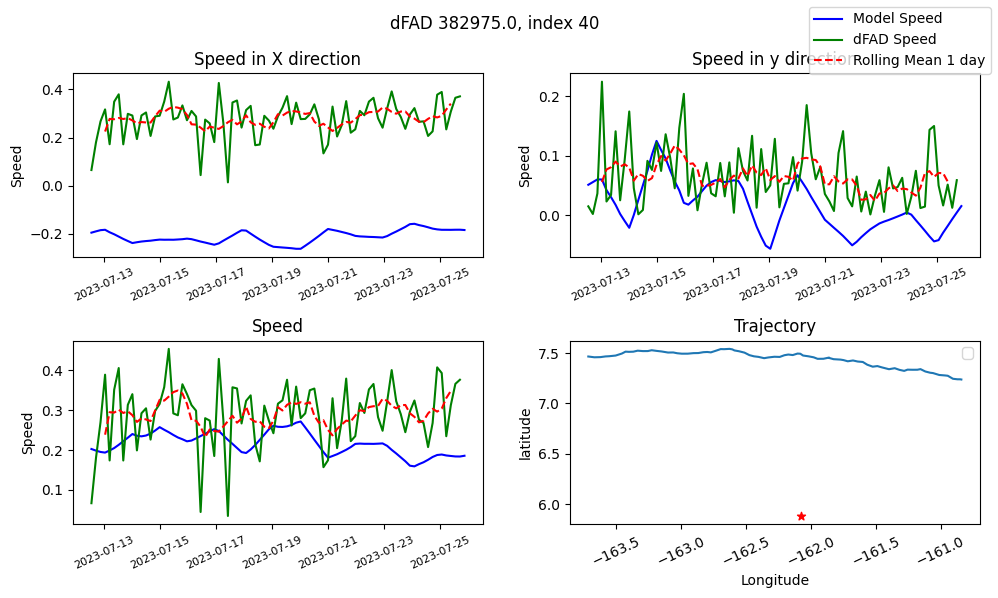

In [10]:

##6 was interesting was almost oposite
n = np.random.randint(0,301)
n= 40
numppoints = ds["numpoints"][n]
times = ds["timelist"][n]
s = pd.Series(times)
without_year = s.dt.strftime('%m-%d')
line2 = ds["y_speed"][n]

fig, ax = plt.subplots(2,2,figsize = (10,6))

xspeedavg = Rolling_mean(ds["x_speed"][n], 6)
##Plotting x direction speeds
line1, = ax[0,0].plot(times,ds["mapped_u"][n], label = "Model Speed", color = "b")
line2, = ax[0,0].plot(times[:-1],ds["x_speed"][n], label = "dFAD Speed", color = "g")
#line3,= ax[0,0].plot(times[:-1],ds["deltax_speed"][n], label = "Delta Speed", color = "k", linestyle = "--", alpha = 0.8)
line4, = ax[0,0].plot(times[:-1],Rolling_mean(ds["x_speed"][n],6), label = "Rolling Mean 1 day", color = "r", linestyle = "--")

ax[0,0].set_ylabel("Speed")
ax[0,0].set_title("Speed in X direction")


##plotting Y direction speeds
ax[0,1].plot(times,ds["mapped_v"][n], label = "Models Speed", color = "b")
ax[0,1].plot(times[:-1],ds["y_speed"][n], label = " dFAD Speed", color = "g")
ax[0,1].plot(times[:-1],Rolling_mean(ds["y_speed"][n],6), label = "Rolling Mean 1 day", color = "r", linestyle = "--")
ax[0,1].set_ylabel("Speed")
ax[0,1].set_title("Speed in y direction")
#ax[0,1].plot(times[:-1],ds["deltay_speed"][n], label = "Delta Speed", color = "k", linestyle = "--", alpha = 0.8)

##plotting Speeds 
ax[1,0].plot(times,ds["mapped_speed"][n], label = "Models Speed", color = "b")
ax[1,0].plot(times[:-1],ds["xy_speed"][n], label = " dFAD Speed", color = "g")
ax[1,0].plot(times[:-1],Rolling_mean(ds["xy_speed"][n],6), label = "Rolling Mean 1 day", color = "r", linestyle = "--")
ax[1,0].set_ylabel("Speed")
ax[1,0].set_title("Speed")
##ax[1,0].plot(times[:-1],ds["delta_speed"][n], label = "Delta Speed", color = "k", linestyle = "--", alpha = 0.8)

OneTrajectory(ax[1,1], ds,n)
ax[1,1] = Palmyra_plot(ax[1,1])
ax[1,1].legend()
ax[1,1].set_title("Trajectory")

ax[0,0].tick_params(axis='x', rotation=25, labelsize = 8)
ax[1,0].tick_params(axis='x', rotation=25, labelsize = 8)
ax[0,1].tick_params(axis='x', rotation=25, labelsize = 8)
ax[1,1].tick_params(axis='x', rotation=25)
#plt.xticks(rotation = 90)
fig.legend(handles = [line1,line2,line4])
fig.suptitle(f"dFAD {ds["Name_ID"][n]}, index {n}")
fig.tight_layout()
fig.savefig(rf"..\Figures\speed_plots\{n}.png")




#### Compairing mean speed vs Mean Error. 

In [11]:
Mspeedxs = []
Mspeedys = []
Mspeeds = []

Merrorxs = []
Merrorys = []
Merrors = []

for i in range(len(ds)):
    Mspeedx = np.nanmean(ds.at[i,"x_speed"])
    Mspeedy = np.nanmean(ds.at[i,"y_speed"])
    Mspeed = np.nanmean(ds.at[i,"xy_speed"])

    Merrorx =  np.abs(np.nanmean(ds.at[i,"deltax_speed"]))
    Merrory =  np.abs(np.nanmean(ds.at[i,"deltay_speed"]))
    Merror  =  np.abs(np.nanmean(ds.at[i,"delta_speed"]))

    Mspeedxs.append(Mspeedx)
    Mspeedys.append(Mspeedy)
    Mspeeds.append(Mspeed)

    Merrorxs.append(Merrorx)
    Merrorys.append(Merrory)
    Merrors.append(Merror)    

C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_16680\3731791433.py:2: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[0].scatter(Mspeedxs, Merrorxs, marker = "x",  edgecolors='k')
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_16680\3731791433.py:3: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[1].scatter(Mspeedys, Merrorys,  marker = "x",  edgecolors='k')
C:\Users\czerfass\AppData\Local\Temp\1\ipykernel_16680\3731791433.py:4: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax[2].scatter(Mspeeds, Merrors,  marker = "x",  edgecolors='k')


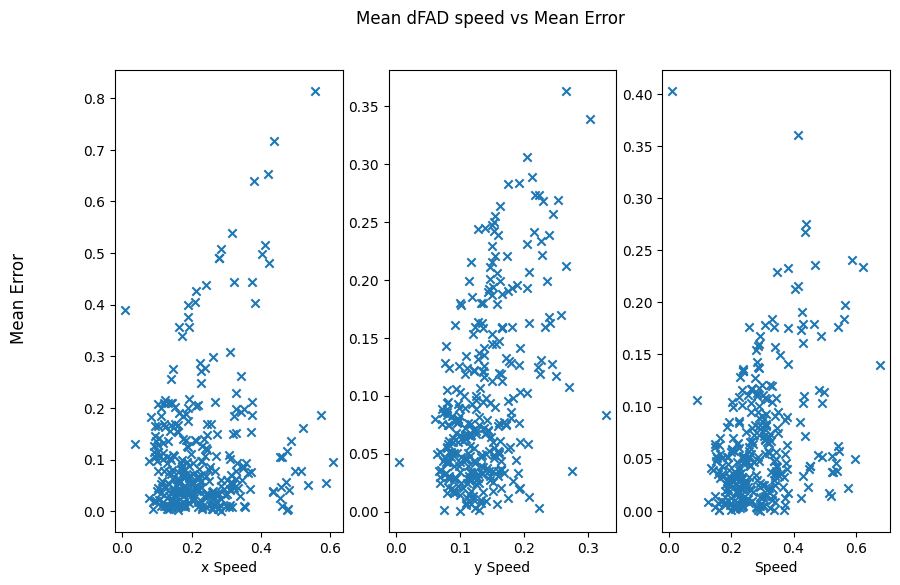

In [31]:
fig, ax = plt.subplots(1,3, figsize = (10,6))
ax[0].scatter(Mspeedxs, Merrorxs, marker = "x",  edgecolors='k')
ax[1].scatter(Mspeedys, Merrorys,  marker = "x",  edgecolors='k')
ax[2].scatter(Mspeeds, Merrors,  marker = "x",  edgecolors='k')
xlabels = ["x Speed", "y Speed", "Speed"]
for i,n in enumerate(xlabels):
    ax[i].set_xlabel(n)
fig.supylabel("Mean Error")
fig.suptitle("Mean dFAD speed vs Mean Error")
fig.savefig(r"..\Figures\Mean_dFAD_speed_vs_error.png")

#### fourier Transform of Rolling avergage speed and speed 


In [13]:
from scipy import signal

In [38]:
n = 200
xspeed = ds.at[n,"x_speed"]
avgspeedx = Rolling_avg_no_nan(xspeed,6)

yspeed = ds.at[n,"y_speed"]
avgspeedy = Rolling_avg_no_nan(yspeed,6)

speed = ds.at[n,"xy_speed"]
avgspeed = Rolling_avg_no_nan(speed,6)

frequeciesx, psdx = signal.welch(xspeed, fs = 0.25, nperseg = 40)
frequeciesxa, psdxa = signal.welch(avgspeedx, fs = 0.25, nperseg = 40)

frequeciesy, psdy = signal.welch(yspeed, fs  =0.25, nperseg = 40)
frequeciesavgy, psdya = signal.welch(avgspeedy, fs  =0.25, nperseg = 40)

frequecies, psd = signal.welch(speed, fs  =0.25,nperseg = 40)
frequeciesavg, psda = signal.welch(avgspeed, fs  =0.25, nperseg = 40)

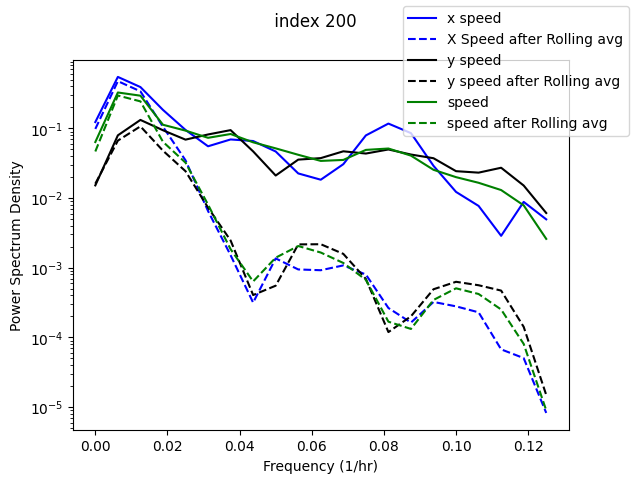

In [39]:
fig, ax = plt.subplots()
ax.plot(frequeciesx, psdx ,label = "x speed", color = "b")
ax.plot(frequeciesxa,psdxa, label = "X Speed after Rolling avg", color = "b", linestyle = "--")
ax.plot(frequeciesy, psdy, label = "y speed", color = "k")
ax.plot(frequeciesavgy, psdya, label = "y speed after Rolling avg", linestyle = "--", color= "k")
ax.plot(frequecies, psd, label = "speed", color = "g")
ax.plot(frequeciesavg, psda, label = "speed after Rolling avg", color = "g", linestyle = "--")
ax.set_xlabel("Frequency (1/hr)")
ax.set_ylabel('Power Spectrum Density')
fig.suptitle(f" index {n}")
fig.legend()
ax.set_yscale("log")
fig.savefig(rf"..\Figures\speed_plots\PowerSpectrum_{n}.png")